In [3]:
import pandas as pd
from sklearn import tree
from statsmodels.formula.api import ols

survey_data = pd.read_csv(r'datasets\Call_center_survey.csv')

In [4]:
survey_data.head()

,Cust_id,Age,Account_balance,Personal_loan_ind,Home_loan_ind,Prime_Customer_ind,Overall_Satisfaction
0,CX01-001,49,23974,1,0,1,Dis Satisfied
1,CX01-002,25,72374,0,1,1,Satisfied
2,CX01-003,32,65532,0,0,1,Satisfied
3,CX01-004,70,28076,0,1,1,Dis Satisfied
4,CX01-005,23,38974,1,1,1,Satisfied


In [5]:
survey_data.describe()

,Age,Account_balance,Personal_loan_ind,Home_loan_ind,Prime_Customer_ind
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,44.772830,41177.138281,0.496107,0.499108,0.576886
std,13.912851,26432.604489,0.500005,0.500019,0.494073
min,19.000000,4904.000000,0.000000,0.000000,0.000000
25%,35.000000,20927.000000,0.000000,0.000000,0.000000
50%,43.000000,34065.000000,0.000000,0.000000,1.000000
75%,55.000000,60264.000000,1.000000,1.000000,1.000000
max,75.000000,109776.000000,1.000000,1.000000,1.000000


In [6]:
survey_data['Overall_Satisfaction'].value_counts()

Overall_Satisfaction
Dis Satisfied    6707
Satisfied        5623
Name: count, dtype: int64

In [7]:
survey_data['Personal_loan_ind'].value_counts()

Personal_loan_ind
0    6213
1    6117
Name: count, dtype: int64

In [8]:
survey_data['Home_loan_ind'].value_counts()

Home_loan_ind
0    6176
1    6154
Name: count, dtype: int64

In [9]:
survey_data['Prime_Customer_ind'].value_counts()

Prime_Customer_ind
1    7113
0    5217
Name: count, dtype: int64

In [4]:
#convert the target variable into binary 0 and 1
survey_data['Overall_Satisfaction'] = survey_data['Overall_Satisfaction'].map({'Satisfied':1, 'Dis Satisfied':0}).astype(int)   

survey_data['Overall_Satisfaction'].value_counts()

Overall_Satisfaction
0    6707
1    5623
Name: count, dtype: int64

In [11]:
survey_data['Overall_Satisfaction'].unique()

array([0, 1])

In [5]:
features = list(survey_data.columns[1:6])
print(features)

['Age', 'Account_balance', 'Personal_loan_ind', 'Home_loan_ind', 'Prime_Customer_ind']


In [6]:
x= survey_data[features]
y= survey_data['Overall_Satisfaction']

In [7]:
from sklearn import tree
DT_Model = tree.DecisionTreeClassifier(max_depth=2)
DT_Model.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [ ]:
# #Drawing the decision tree
# from IPython.display import Image
# from sklearn.externals.six import StringIO

# import pydotplus
# dot_data = StringIO()
# tree.export_graphviz(DT_Model, out_file=dot_data,  
#                 filled=True, rounded=True,
#                 special_characters=True,feature_names = features,class_names=['Dis Satisfied','Satisfied'])
# graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
# Image(graph.create_png())

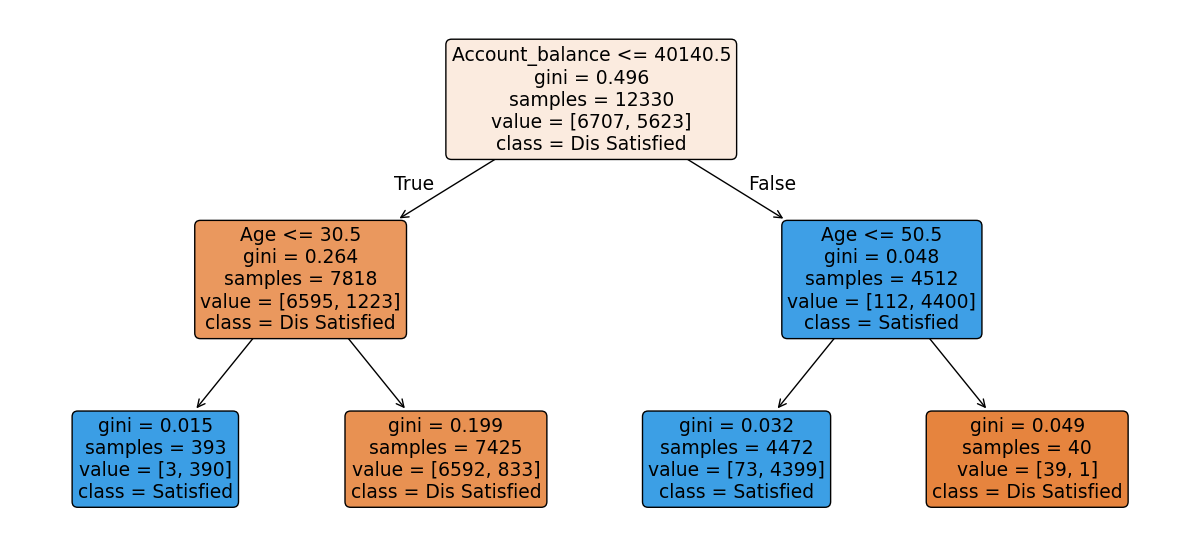

|--- Account_balance <= 40140.50
|   |--- Age <= 30.50
|   |   |--- class: 1
|   |--- Age >  30.50
|   |   |--- class: 0
|--- Account_balance >  40140.50
|   |--- Age <= 50.50
|   |   |--- class: 1
|   |--- Age >  50.50
|   |   |--- class: 0



In [9]:
# Drawing the decision tree using sklearn only
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))
plot_tree(DT_Model, filled=True, rounded=True, feature_names=features, class_names=['Dis Satisfied','Satisfied'])
plt.show()
print(export_text(DT_Model, feature_names=features))

In [10]:
# Tree validation and accuracy

predict1 = DT_Model.predict(x)
print(predict1)

[0 1 1 ... 1 1 1]


In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, predict1)
print(cm)

[[6631   76]
 [ 834 4789]]


In [14]:
print(sum(cm))
print(sum(sum(cm )))
total= sum(sum(cm))

[7465 4865]
12330


In [15]:
# calculate accuracy

accuracy = (cm[0,0] + cm[1,1]) / total
print("Accuracy:", accuracy)

Accuracy: 0.9261962692619627
